# Basic Data Visualizations in Pandas

This tutorial demonstrates how to create basic data visualizations using the Pandas `DataFrame.plot` method. We will cover:

1. Line Charts
2. Bar Charts
3. Scatter Plots
4. Histograms
5. Pie Charts
6. Heatmaps (using Pandas + Seaborn)

Let's get started!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Create a sample DataFrame
data = {
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'],
    'Sales': [250, 300, 400, 350, 500, 600],
    'Expenses': [200, 220, 300, 280, 320, 400],
    'Profit': [50, 80, 100, 70, 180, 200]
}

df = pd.DataFrame(data)
df


,Month,Sales,Expenses,Profit
0,Jan,250,200,50
1,Feb,300,220,80
2,Mar,400,300,100
3,Apr,350,280,70
4,May,500,320,180
5,Jun,600,400,200


## 1. Line Chart

Line charts are useful for showing trends over time. We can plot multiple columns on the same chart.


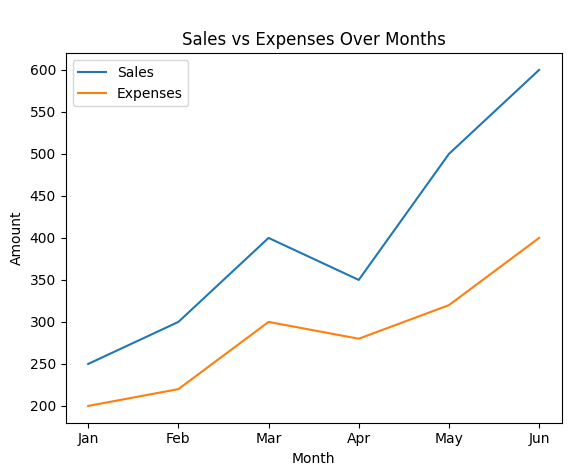

In [3]:
# Plot Sales and Expenses as a line chart
df.plot(x='Month', y=['Sales', 'Expenses'], kind='line', marker='', title='\nSales vs Expenses Over Months')
plt.ylabel('Amount')
plt.show()


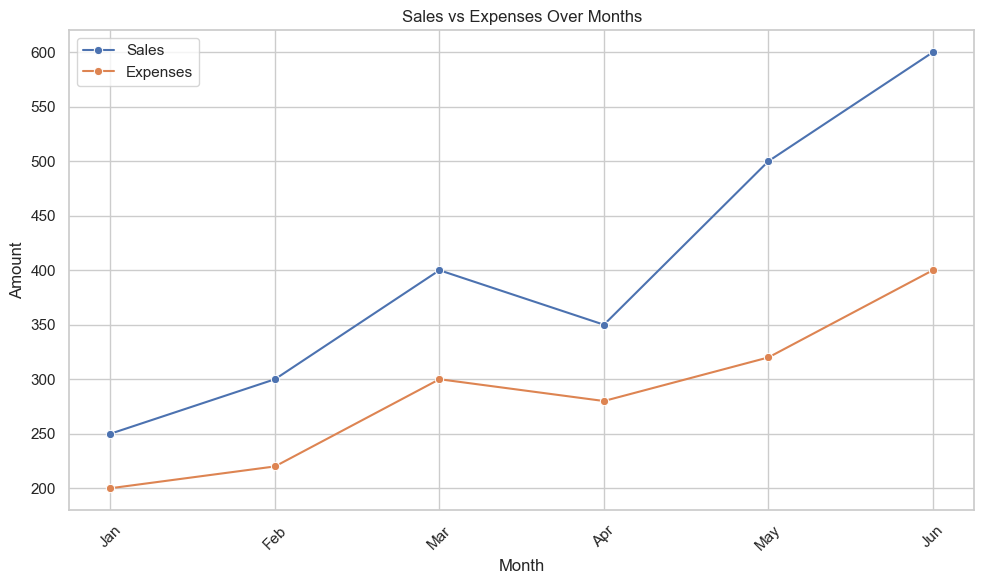

In [4]:

import seaborn as sns
import matplotlib.pyplot as plt

# If df currently has columns: Month, Sales, Expenses
# Reshape to long format for seaborn
df_long = df.melt(id_vars='Month', value_vars=['Sales', 'Expenses'],
                  var_name='Metric', value_name='Amount')

# Optional: set seaborn style
sns.set(style='whitegrid')

# Create the plot with seaborn
plt.figure(figsize=(10, 6))
ax = sns.lineplot(data=df_long, x='Month', y='Amount', hue='Metric', marker='o')

# Use pyplot for labels and title
plt.title('Sales vs Expenses Over Months')
plt.xlabel('Month')
plt.ylabel('Amount')

# Optional: improve x-tick readability (especially if Month are strings)
plt.xticks(rotation=45)

# Optional: tweak legend title (Seaborn sets it from 'hue')
ax.legend(title='')
plt.tight_layout()


In [20]:
df_long, df

(   Month    Metric  Amount
 0    Jan     Sales     250
 1    Feb     Sales     300
 2    Mar     Sales     400
 3    Apr     Sales     350
 4    May     Sales     500
 5    Jun     Sales     600
 6    Jan  Expenses     200
 7    Feb  Expenses     220
 8    Mar  Expenses     300
 9    Apr  Expenses     280
 10   May  Expenses     320
 11   Jun  Expenses     400,
   Month  Sales  Expenses  Profit
 0   Jan    250       200      50
 1   Feb    300       220      80
 2   Mar    400       300     100
 3   Apr    350       280      70
 4   May    500       320     180
 5   Jun    600       400     200)

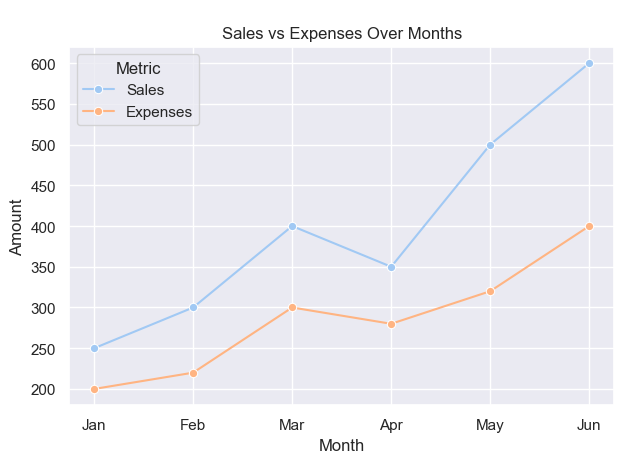

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
 
# Optional: set a nice theme
#sns.set_theme(style="darkgrid", palette="pastel")
 
# Reshape to long-form for seaborn
df_long = df.melt(
    id_vars='Month',
    value_vars=['Sales', 'Expenses'],
    var_name='Metric',
    value_name='Amount'
)
 
# Plot with seaborn
ax = sns.lineplot(data=df_long, x='Month', y='Amount', hue='Metric', marker='o')
 
# Use matplotlib for titles, labels, etc.
plt.title('\nSales vs Expenses Over Months')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.legend(title='Metric', loc='best')
plt.tight_layout()
 

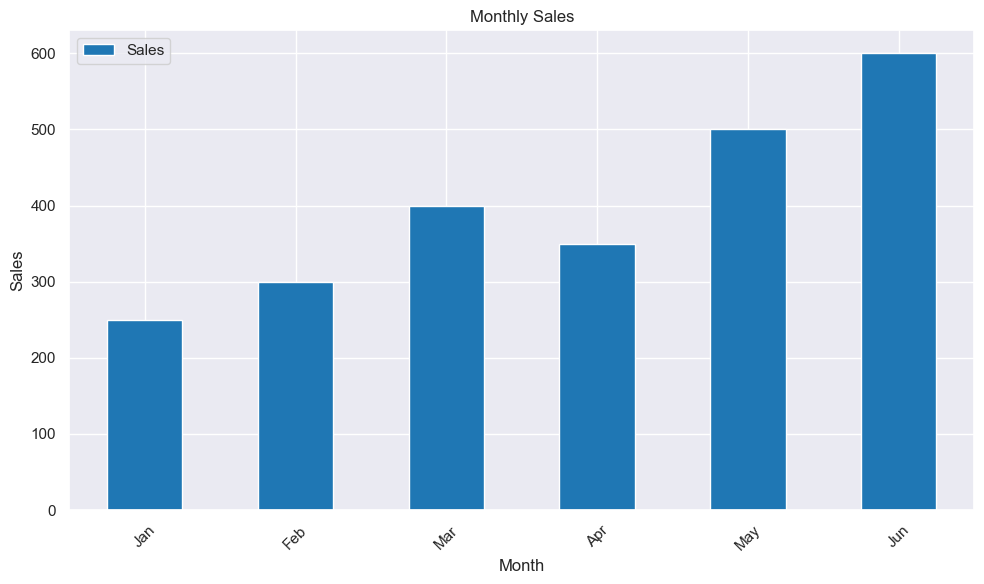

In [39]:

import matplotlib.pyplot as plt

ax = df.plot(x='Month', y='Sales', kind='bar', color='#1f77b4', figsize=(10, 6))
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


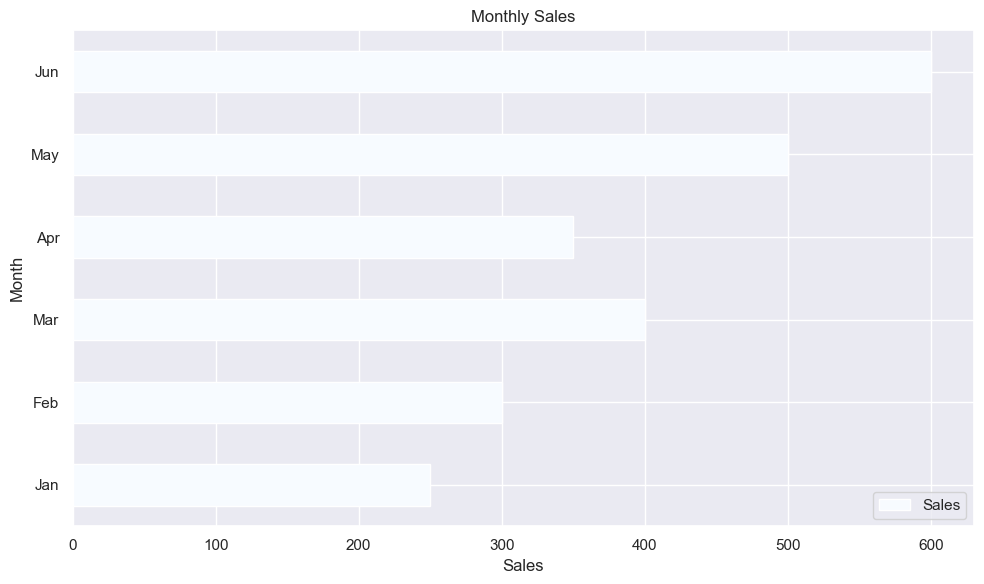

In [50]:

import matplotlib.pyplot as plt

ax = df.plot(
    x='Month', y='Sales',
    kind='barh',
    figsize=(10, 6),
    colormap='Blues'    # gradient from light to dark
)

plt.title('Monthly Sales')
plt.xlabel('Sales')
plt.ylabel('Month')
plt.tight_layout()
plt.show()




## 2. Bar Chart / Column Chart

Bar / Column charts are great for comparing quantities across categories.


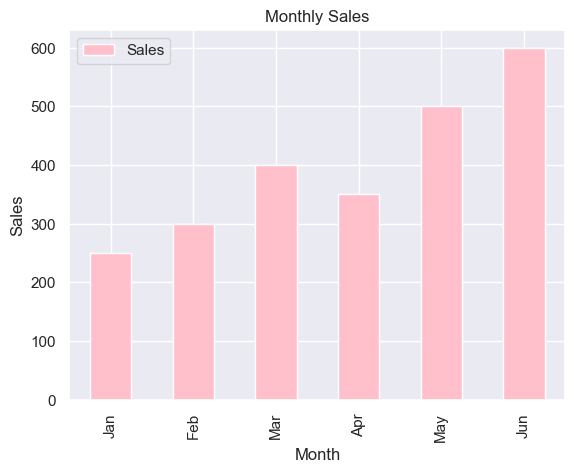

In [35]:
# Plot Sales as a bar chart
df.plot(x='Month', y='Sales', kind='bar', color='pink', title='Monthly Sales')
plt.ylabel('Sales')
plt.show()


In [36]:
ax

<Axes: title={'center': '\nSales vs Expenses Over Months'}, xlabel='Month', ylabel='Amount'>

## 3. Scatter Plot

Scatter plots show the relationship between two variables.


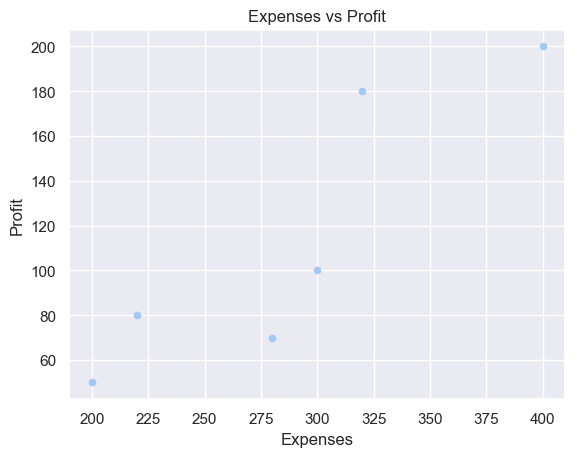

In [52]:
# Plot Expenses vs Profit as a scatter plot
df.plot(x='Expenses', y='Profit', kind='scatter', title='Expenses vs Profit')
plt.show()


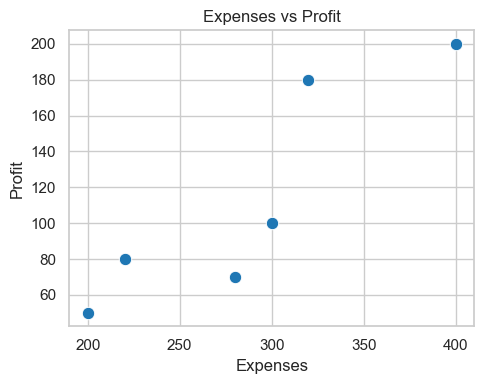

In [54]:

import seaborn as sns
import matplotlib.pyplot as plt

# Optional: set style
sns.set(style='whitegrid')

plt.figure(figsize=(5, 4))
sns.scatterplot(data=df, x='Expenses', y='Profit', color='#1f77b4', s=80)  # s controls marker size

# Matplotlib for title and labels
plt.title('Expenses vs Profit')
plt.xlabel('Expenses')
plt.ylabel('Profit')

plt.tight_layout()
plt.show()


## 4. Histogram

Histograms display the distribution of a variable.


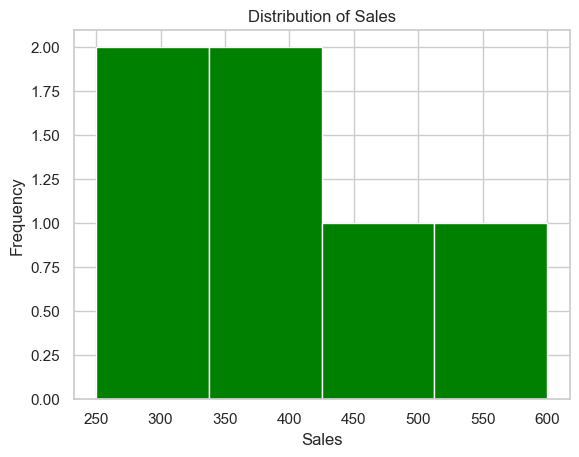

In [56]:
# Plot histogram of Sales
df['Sales'].plot(kind='hist', bins=4, color='green', title='Distribution of Sales')
plt.xlabel('Sales')
plt.show()


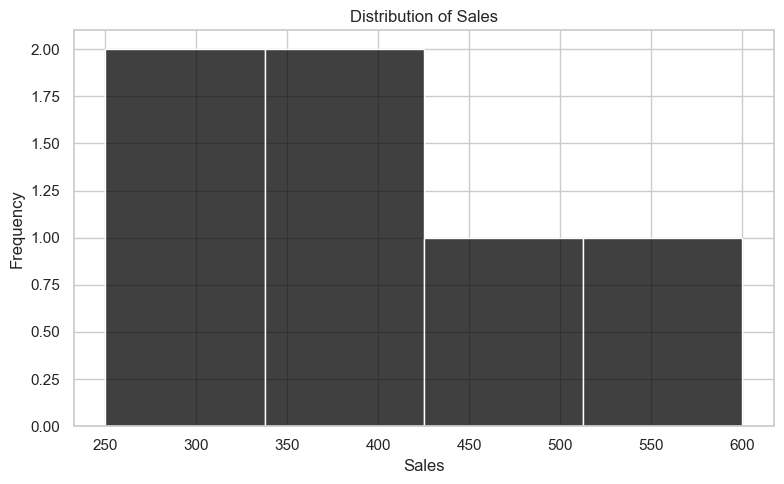

In [61]:
plt.figure(figsize=(8, 5))
ax = sns.histplot(data=df, x='Sales', bins=4, color='black')
 
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
 


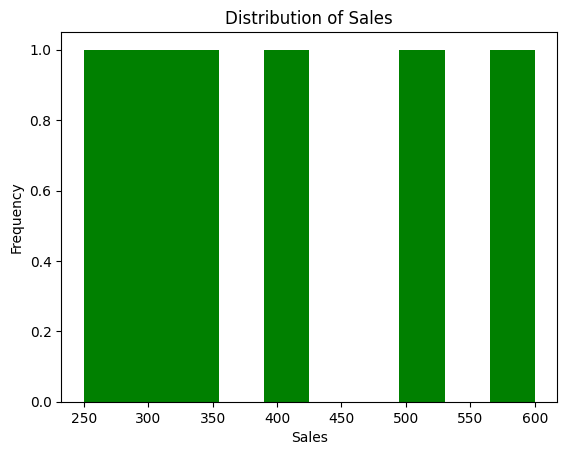

In [7]:
# Plot histogram of Sales
df['Sales'].plot(kind='hist', color='green', title='Distribution of Sales')
plt.xlabel('Sales')
plt.show()

## 5. Pie Chart

Pie charts show proportions of categories.


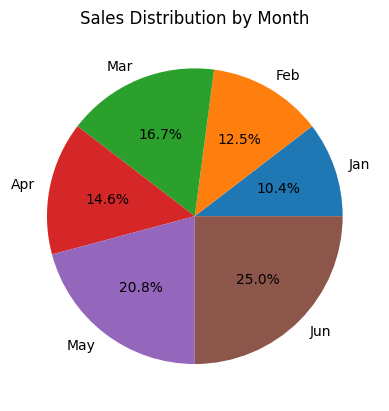

In [8]:
# Plot pie chart of Sales by Month
df.set_index('Month')['Sales'].plot(kind='pie', autopct='%1.1f%%', title='Sales Distribution by Month')
plt.ylabel('')
plt.show()


## 6. Heatmap

Heatmaps are useful for visualizing correlations or values in a matrix format. We'll use Seaborn for this.


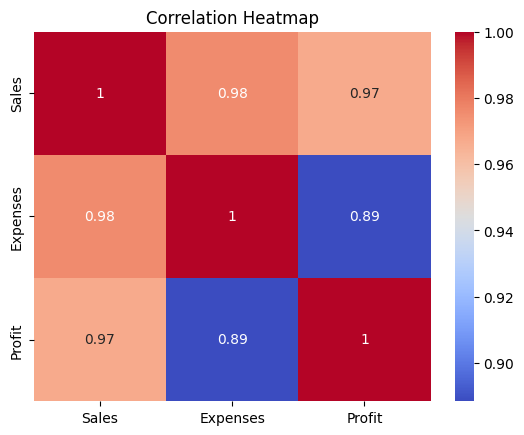

In [9]:
# Compute correlation matrix
corr = df[['Sales', 'Expenses', 'Profit']].corr()

# Plot heatmap using seaborn
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [10]:
df

,Month,Sales,Expenses,Profit
0,Jan,250,200,50
1,Feb,300,220,80
2,Mar,400,300,100
3,Apr,350,280,70
4,May,500,320,180
5,Jun,600,400,200


In [11]:
corr = df[['Sales', 'Expenses', 'Profit']]
corr

,Sales,Expenses,Profit
0,250,200,50
1,300,220,80
2,400,300,100
3,350,280,70
4,500,320,180
5,600,400,200


In [24]:
corr.corr()

,Sales,Expenses,Profit
Sales,1.000000,0.976003,0.967074
Expenses,0.976003,1.000000,0.888449
Profit,0.967074,0.888449,1.000000
